# Machine Learning LAB 2B: LINEAR REGRESSION

Course 2025/26: *F. Chiariotti*

The notebook contains some simple tasks to be performed with **LINEAR REGRESSION MODELS**.

Complete all the **required code sections**.

### IMPORTANT for the exam:

The functions you might be required to implement in the exam will have the same signature and parameters as the ones in the labs

## VR traffic prediction

In this notebook, we will explore the prediction of Virtual Reality (VR) traffic. The data come from the paper:

Lecci, Mattia, _et al._ "An open framework for analyzing and modeling XR network traffic." IEEE Access 9 (2021): 129782-129795.

The VR game Virus Popper was instantiated on a computer through the RiftCat application: the user could then see the virtual content on their phone, which was strapped to their head with a Cardboard viewer. The file virus_popper.csv contains three columns from the traffic capture:
idx    | frame size (B) |  time (s)
0      | 38424          |  0.0
1      | 39801          |  0.01944
...

The game was run at 60 frames per second, with a target rate of 30 Mb/s. The task is then to predict the size of the next frame, given the past N frames. This was explored in another paper:

Chiariotti, Federico, _et al._ "Temporal characterization and prediction of vr traffic: A network slicing use case." IEEE Transactions on Mobile Computing 23.5 (2023): 3890-3908.

---

## Import all the necessary Python libraries

In [36]:
import numpy as np
import pandas as pd
import random as rnd
from matplotlib import pyplot as plt
from sklearn import linear_model, preprocessing
from sklearn.model_selection import train_test_split

np.random.seed(1)

def load_dataset(filename):
    data_train = pd.read_csv(filename)
    data = data_train.iloc[:, 1].values # Get the second column (frame size) as the input
    return data

# Load the dataset
data = load_dataset('data/virus_popper.csv')

## Prepare the data and create training and test sets

In this case, we are learning a time series: let us consider a memory of 2 samples, i.e., use X[n-1] and X[n-2] to predict X[n].

In [37]:
# Normalize the dataset
avg_size = np.mean(data)
norm_data = np.asarray(data) / avg_size

# Compute the splits and prepare the columns
m_training = int(0.75*norm_data.shape[0])

X_training = np.ones([m_training - 2, 3])
X_training[:,1] = norm_data[: m_training - 2]
X_training[:,2] = norm_data[1 : m_training - 1]
Y_training = norm_data[2 : m_training]


X_test = np.ones([norm_data.shape[0] - m_training - 2, 3])
X_test[:,1] = norm_data[m_training : -2]
X_test[:,2] = norm_data[m_training + 1 : -1]
Y_test = norm_data[m_training + 2:]

print(np.shape(X_training), np.shape(Y_training), np.shape(X_test), np.shape(Y_test))
print(X_test)
print(Y_test)

(25878, 3) (25878,) (8625, 3) (8625,)
[[1.         0.82701864 0.98963757]
 [1.         0.98963757 0.81506303]
 [1.         0.81506303 0.82509864]
 ...
 [1.         1.11350159 0.93269916]
 [1.         0.93269916 0.98671723]
 [1.         0.98671723 0.99436495]]
[0.81506303 0.82509864 0.86324044 ... 0.98671723 0.99436495 0.94894653]


## Least Squares linear regression

Train and evaluate the LS regressor on the data

In [38]:
# Least squares solution
def least_squares(X_matrix: np.ndarray, labels: np.ndarray) -> np.ndarray:
    ## TODO: Run the LS algorithm without regularization
    
    A = np.dot(X_matrix.T, X_matrix)
    b = np.dot(X_matrix.T, labels)
    
    coeff = np.linalg.solve(A, b)
    
    return coeff

def evaluate_model(x, y, coeff):
    ## TODO: Return the average MSE for the set over which we evaluate
    return np.mean((np.dot(x, coeff) - y)**2)

In [39]:
# Run the LS training and test it on the test data
trained_model = least_squares(X_training, Y_training)
mse = evaluate_model(X_test, Y_test, trained_model)
print('Model coefficients:', trained_model)
print('Root MSE:', np.sqrt(mse) * avg_size)

Model coefficients: [0.36986742 0.20348677 0.42565451]
Root MSE: 7712.354721539328


---

## Least Squares with Tikhonov regularization

Perform K-fold cross validation with $\lambda\in\{0, 0.1, 1, 10\}$

In [40]:
# Least squares solution
def regularized_least_squares(X_matrix: np.ndarray, labels: np.ndarray, lambda_par: np.ndarray) -> None:
    ## TODO: Run the LS algorithm with regularization
    
    A = np.dot(X_matrix.T, X_matrix)
    A += lambda_par*np.eye(A.shape[0])
    b = np.dot(X_matrix.T, labels)
    
    coeff = np.linalg.solve(A, b)
    
    return coeff


def K_fold(x_train: np.ndarray, y_train: np.ndarray, lambda_vec: np.ndarray, k: int):
    ## TODO:Perform K-fold cross-validation
    
    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    x_train = x_train[indices]
    y_train = y_train[indices]

    folds_x = np.array_split(x_train, k)
    folds_y = np.array_split(y_train, k)

    val_results = []

    for lambda_par in lambda_vec:
        fold_scores = []

        for val_fold in range(k):
            # Validation set
            x_val = folds_x[val_fold]
            y_val = folds_y[val_fold]

            # Training set = concatenate all other folds
            x_tr = np.concatenate([folds_x[j] for j in range(k) if j != val_fold])
            y_tr = np.concatenate([folds_y[j] for j in range(k) if j != val_fold])

            # Train with this lambda
            coeff = regularized_least_squares(x_tr, y_tr, lambda_par)
            
            # Validation MSE
            mse = evaluate_model(x_val, y_val, coeff)
            fold_scores.append(mse)

        # Average validation score for this lambda
        val_results.append(np.mean(fold_scores))

    # Select lambda that minimizes the average MSE
    best_idx = np.argmin(val_results)
    best_lambda = lambda_vec[best_idx]

    # Train final model on all training data using best lambda
    best_model = regularized_least_squares(x_train, y_train, best_lambda)
    best_perf = evaluate_model(x_train, y_train, best_model)
    
    models = []
    results = []
    for i, lambda_par in enumerate(lambda_vec):
        models.append(regularized_least_squares(x_train, y_train, lambda_par))
        results.append(evaluate_model(x_train, y_train, models[i]))

    return best_model, best_perf, models, results

[0.36946549 0.20482646 0.4246606 ] [np.float64(0.021415965688659378), np.float64(0.021415968592588173), np.float64(0.021415977246966065), np.float64(0.021415991566692587), np.float64(0.021416011467998222), np.float64(0.02141603686842133), np.float64(0.021416067686785518), np.float64(0.0214161038431774), np.float64(0.021416145258924907), np.float64(0.021416191856575898), np.float64(0.021416243559877247), np.float64(0.021416300293754298), np.float64(0.02141636198429075), np.float64(0.021416428558708928), np.float64(0.021416499945350338), np.float64(0.021416576073656757), np.float64(0.02141665687415154), np.float64(0.021416742278421348), np.float64(0.021416832219098198), np.float64(0.021416926629841883), np.float64(0.02141702544532269)]


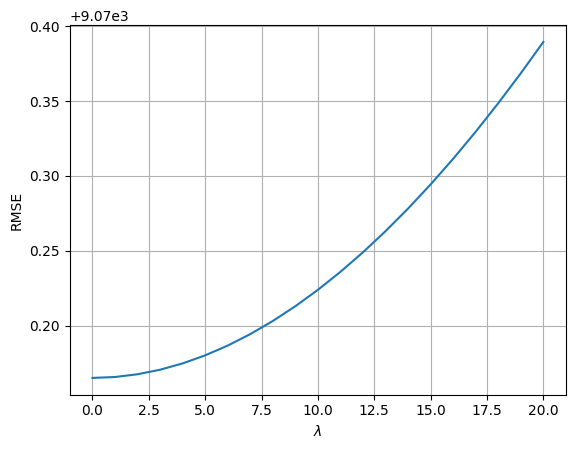

In [41]:
# Run the training with K-fold cross-validation and plot the score
K = 5
lambda_par = range(21)

best_model, best_perf, models, results = K_fold(X_training, Y_training, lambda_par, K)
print(best_model, results)
plt.plot(lambda_par, np.sqrt(results) * avg_size)
plt.xlabel(r'$\lambda$')
plt.ylabel('RMSE')
plt.grid()
plt.show()


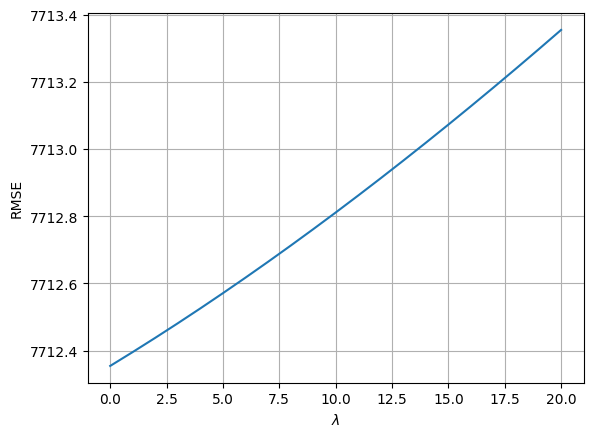

In [42]:
# Plot the results for the regularized models on the test set
test_scores = np.zeros(len(models))

for i in range(len(models)):
    test_scores[i] = evaluate_model(X_test, Y_test, models[i])

plt.plot(lambda_par, np.sqrt(test_scores) * avg_size)
plt.xlabel(r'$\lambda$')
plt.ylabel('RMSE')
plt.grid()
plt.show()